<a href="https://colab.research.google.com/github/NikitaIvagin/ml-portfolio/blob/main/nlp/fake_news_detection/Fake_news_Passive_Aggressive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Устанавливаем необходимые библиотеки
!pip install -q seaborn
import numpy as np
import pandas as pd
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
url = "https://storage.yandexcloud.net/academy.ai/practica/fake_news.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
# Разделим выборку на train (85%) и test (15%)
X = df[['title', 'text']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.15,
    random_state = 42,
    stratify = y  # Сохраняем пропорции классов
)

# Создаем DataFrame для каждой выборки
train_data = pd.concat([X_train, y_train], axis = 1).reset_index(drop = True)
test_data = pd.concat([X_test, y_test], axis = 1).reset_index(drop = True)

# Проверяем размеры выборок
print("\nРазмеры выборок:")
print(f"Обучающая выборка: {train_data.shape[0]}")
print(f"Тестовая выборка: {test_data.shape[0]}")

# Проверяем распределение классов в каждой выборке. Для тестовой баланс классов менее важен, но выведем и ее тоже
print("\nРаспределение классов в обучающей выборке:")
print(train_data['label'].value_counts())

print("\nРаспределение классов в тестовой выборке:")
print(test_data['label'].value_counts())


Размеры выборок:
Обучающая выборка: 5384
Тестовая выборка: 951

Распределение классов в обучающей выборке:
label
REAL    2695
FAKE    2689
Name: count, dtype: int64

Распределение классов в тестовой выборке:
label
REAL    476
FAKE    475
Name: count, dtype: int64


<Axes: title={'center': 'Распределение статей в тренировочной выборке'}, xlabel='Правдивость', ylabel='Кол-во'>

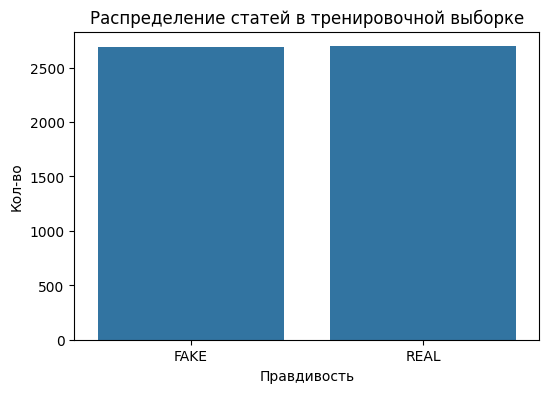

In [ ]:
# Визуализируем распределение
plt.figure(figsize = (6,4))
plt.xlabel('Правдивость')
plt.ylabel('Кол-во')
plt.title("Распределение статей в тренировочной выборке")
sns.countplot(x = "label", data = train_data)

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    max_features = 10000,  # Максимум 10000 слов
    stop_words = 'english',  # Удаляем стоп-слова
    ngram_range = (1, 2),  # Используем униграммы и биграммы
    min_df = 2,  # Минимальная частота слова в документах
    max_df = 0.95  # Максимальная частота слова (удаляем слишком частые слова)
)

# Объединяем текст с заголовком для лучшего представления
train_texts = (train_data['title'] + ' ' + train_data['text']).values
test_texts = (test_data['title'] + ' ' + test_data['text']).values

X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
X_test_tfidf = tfidf_vectorizer.transform(test_texts)

print(f"Размер TF-IDF матрицы для обучения: {X_train_tfidf.shape}")
print(f"Размер TF-IDF матрицы для тестирования: {X_test_tfidf.shape}")

Размер TF-IDF матрицы для обучения: (5384, 10000)
Размер TF-IDF матрицы для тестирования: (951, 10000)


In [ ]:
# Преобразуем текстовые метки в числовые
label_mapping = {'FAKE': 0, 'REAL': 1}

y_train = train_data['label'].map(label_mapping).values
y_test = test_data['label'].map(label_mapping).values

print(f"Распределение классов в обучающей выборке: {np.bincount(y_train)}")

Распределение классов в обучающей выборке: [2689 2695]


In [ ]:
clf = PassiveAggressiveClassifier(
    loss = "squared_hinge",
    C = 1.0,
    max_iter = 1000,
    random_state = 42,
    tol = 0.0001
)
clf = clf.fit(X_train_tfidf, y_train)

In [ ]:
predicted = clf.predict(X_test_tfidf)
print("Точность на тестовых данных: %.3f" % accuracy_score(y_test, predicted))

Точность на тестовых данных: 0.940


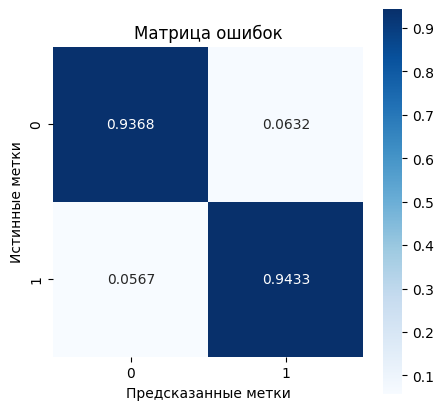

In [ ]:
def show_confusion_matrix(y_test, predicted):
  # Вычисление матрицы ошибок и ее нормализация
  plt.figure(figsize = (5,5))
  confusion = confusion_matrix(y_test, predicted)
  confusion_normalized = confusion / confusion.sum(axis = 1, keepdims = True)
  axis_labels = range(2)
  ax = sns.heatmap(
      confusion_normalized, xticklabels = axis_labels, yticklabels = axis_labels,
      cmap = 'Blues', annot = True, fmt = '.4f', square = True)
  plt.title("Матрица ошибок")
  plt.ylabel("Истинные метки")
  plt.xlabel("Предсказанные метки")

show_confusion_matrix(y_test, predicted)
# Получили хорошую точность: ложные положительные и ложные отрицательные
# классификации составляют менее 6%

In [ ]:
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       475
           1       0.94      0.94      0.94       476

    accuracy                           0.94       951
   macro avg       0.94      0.94      0.94       951
weighted avg       0.94      0.94      0.94       951



Таким образом, получили систему с достаточно хорошей точностью, которую можно дообучать дальше. При обучении важно помнить, что PassiveAgressive алгоритм чувствителен к порядку вводимых данных, поэтому перед обучением нужно их перемешивать.